## Problem 4

Computing PR saturation curve for CO2...
T= 220.000 K  Psat=  5.93635 bar  ZL= 0.0117  ZV= 0.9175
T= 222.120 K  Psat=  6.47773 bar  ZL= 0.0128  ZV= 0.9119
T= 224.240 K  Psat=  7.05598 bar  ZL= 0.0139  ZV= 0.9061
T= 226.360 K  Psat=  7.67271 bar  ZL= 0.0151  ZV= 0.9001
T= 228.480 K  Psat=  8.32954 bar  ZL= 0.0164  ZV= 0.8938


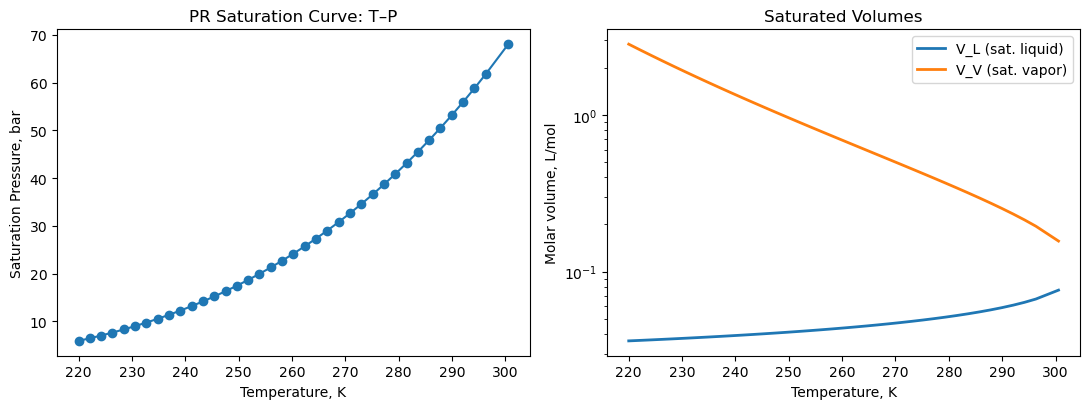

In [9]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Pure-component saturation with Peng–Robinson EOS (phi^L = phi^V)
Outputs Psat(T) *and* saturated liquid/vapor Z and molar volumes.
Units: bar, L/mol, K
"""
import math
from typing import List, Optional, Tuple

try:
    import numpy as np
except Exception:
    class _NP:
        @staticmethod
        def linspace(a, b, n):
            step = (b - a) / (n - 1)
            return [a + i * step for i in range(n)]
    np = _NP()

R = 0.08314472  # bar·L/(mol·K)

def pr_params(Tc: float, Pc: float, omega: float) -> Tuple[float, float, float]:
    a = 0.45724 * R**2 * Tc**2 / Pc
    b = 0.07780 * R * Tc / Pc
    kappa = 0.37464 + 1.54226 * omega - 0.26992 * omega**2
    return a, b, kappa

def alpha_pr(T: float, Tc: float, kappa: float) -> float:
    Tr = T / Tc
    return (1 + kappa * (1 - math.sqrt(Tr))) ** 2

def A_B(a: float, b: float, alpha: float, T: float, P: float) -> Tuple[float, float]:
    A = a * alpha * P / (R**2 * T**2)
    B = b * P / (R * T)
    return A, B

def _real_cubic_roots(a3: float, a2: float, a1: float, a0: float) -> List[float]:
    if abs(a3) < 1e-18:
        if abs(a2) < 1e-18:
            if abs(a1) < 1e-18:
                return []
            return [-a0 / a1]
        disc = a1 * a1 - 4 * a2 * a0
        if disc < 0:
            return []
        if abs(disc) < 1e-18:
            return [-a1 / (2 * a2)]
        rt = math.sqrt(disc)
        return [(-a1 - rt) / (2 * a2), (-a1 + rt) / (2 * a2)]
    p = a2 / a3
    q = a1 / a3
    r = a0 / a3
    shift = p / 3.0
    Acoef = q - p * p / 3.0
    Bcoef = (2 * p**3) / 27.0 - p * q / 3.0 + r
    disc = (Bcoef / 2.0) ** 2 + (Acoef / 3.0) ** 3
    roots = []
    if disc > 0:
        sqrt_disc = math.sqrt(disc)
        u = -Bcoef / 2.0 + sqrt_disc
        v = -Bcoef / 2.0 - sqrt_disc
        u_c = math.copysign(abs(u) ** (1 / 3.0), u) if u != 0 else 0.0
        v_c = math.copysign(abs(v) ** (1 / 3.0), v) if v != 0 else 0.0
        x = u_c + v_c
        roots = [x - shift]
    elif abs(disc) < 1e-18:
        if abs(Bcoef) < 1e-18:
            x = 0.0
            roots = [x - shift]
        else:
            u = math.copysign(abs(-Bcoef / 2.0) ** (1 / 3.0), -Bcoef / 2.0)
            roots = [2 * u - shift, -u - shift]
    else:
        rho = math.sqrt(-Acoef**3 / 27.0)
        theta = math.acos(-Bcoef / (2.0 * rho))
        m = 2 * math.sqrt(-Acoef / 3.0)
        x1 = m * math.cos(theta / 3.0) - shift
        x2 = m * math.cos((theta + 2 * math.pi) / 3.0) - shift
        x3 = m * math.cos((theta + 4 * math.pi) / 3.0) - shift
        roots = [x1, x2, x3]
    roots = [float(r) for r in roots]
    roots.sort()
    return roots

def pr_Z_roots(A: float, B: float) -> List[float]:
    a3 = 1.0
    a2 = -(1.0 - B)
    a1 = A - 3 * B * B - 2 * B
    a0 = -(A * B - B * B - B**3)
    roots = _real_cubic_roots(a3, a2, a1, a0)
    roots = [z for z in roots if z > -1e-10]
    return roots

def lnphi_pure(Z: float, A: float, B: float) -> float:
    sqrt2 = math.sqrt(2.0)
    term1 = Z - 1.0 - math.log(max(Z - B, 1e-300))
    term2 = (A / (2.0 * sqrt2 * B)) * math.log(
        max((Z + (1.0 + sqrt2) * B) / (Z + (1.0 - sqrt2) * B), 1e-300)
    )
    return term1 - term2

def lnphi_L_minus_V_and_roots(T: float, P: float, Tc: float, Pc: float, omega: float):
    a, b, kappa = pr_params(Tc, Pc, omega)
    alpha = alpha_pr(T, Tc, kappa)
    A, B = A_B(a, b, alpha, T, P)
    roots = pr_Z_roots(A, B)
    if len(roots) < 2:
        return None, None, None, None, None
    Z_L = min(roots)
    Z_V = max(roots)
    lnphi_L = lnphi_pure(Z_L, A, B)
    lnphi_V = lnphi_pure(Z_V, A, B)
    return lnphi_L - lnphi_V, Z_L, Z_V, A, B

def find_psat_at_T(T: float, Tc: float, Pc: float, omega: float,
                   Pmin: float = 1e-6, Pmax: Optional[float] = None, nscan: int = 200):
    if Pmax is None:
        Pmax = 0.999 * Pc
    Ps = [Pmin * (Pmax / Pmin) ** (i / (nscan - 1)) for i in range(nscan)]
    vals = []
    for P in Ps:
        F, ZL, ZV, A, B = lnphi_L_minus_V_and_roots(T, P, Tc, Pc, omega)
        if F is not None and math.isfinite(F):
            vals.append((P, F))
    if len(vals) < 2:
        return None
    bracket = None
    for (P1, F1), (P2, F2) in zip(vals[:-1], vals[1:]):
        if F1 == 0.0:
            P = P1
            _, ZL, ZV, _, _ = lnphi_L_minus_V_and_roots(T, P, Tc, Pc, omega)
            VL = ZL * R * T / P
            VV = ZV * R * T / P
            return P, ZL, ZV, VL, VV
        if F1 * F2 < 0.0:
            bracket = (P1, F1, P2, F2)
            break
    if bracket is None:
        vals_sorted = sorted(vals, key=lambda t: abs(t[1]))
        if len(vals_sorted) >= 2:
            P1, F1 = vals_sorted[0]
            P2, F2 = vals_sorted[1]
            for _ in range(50):
                if abs(F2 - F1) < 1e-14:
                    break
                P_new = P2 - F2 * (P2 - P1) / (F2 - F1)
                P_new = max(Pmin, min(P_new, Pmax))
                F_new, ZL, ZV, _, _ = lnphi_L_minus_V_and_roots(T, P_new, Tc, Pc, omega)
                if F_new is None:
                    P_new = 0.5 * (P2 + P1)
                    F_new, ZL, ZV, _, _ = lnphi_L_minus_V_and_roots(T, P_new, Tc, Pc, omega)
                    if F_new is None:
                        break
                if abs(F_new) < 1e-10:
                    VL = ZL * R * T / P_new
                    VV = ZV * R * T / P_new
                    return P_new, ZL, ZV, VL, VV
                P1, F1, P2, F2 = P2, F2, P_new, F_new
        return None
    P1, F1, P2, F2 = bracket
    ZL=ZV=VL=VV=None
    for _ in range(80):
        Pm = 0.5 * (P1 + P2)
        Fm, ZL, ZV, _, _ = lnphi_L_minus_V_and_roots(T, Pm, Tc, Pc, omega)
        if Fm is None:
            Pm = math.sqrt(P1 * P2)
            Fm, ZL, ZV, _, _ = lnphi_L_minus_V_and_roots(T, Pm, Tc, Pc, omega)
            if Fm is None:
                break
        if abs(Fm) < 1e-12:
            VL = ZL * R * T / Pm
            VV = ZV * R * T / Pm
            return Pm, ZL, ZV, VL, VV
        if F1 * Fm < 0:
            P2, F2 = Pm, Fm
        else:
            P1, F1 = Pm, Fm
    if ZL is None or ZV is None:
        return None
    Pfin = 0.5 * (P1 + P2)
    VL = ZL * R * T / Pfin
    VV = ZV * R * T / Pfin
    return Pfin, ZL, ZV, VL, VV

def compute_psat_curve_pr(Tc: float, Pc: float, omega: float,
                          T_min: Optional[float] = None,
                          T_max: Optional[float] = None,
                          nT: int = 60):
    if T_max is None:
        T_max = 0.999 * Tc
    if T_min is None:
        T_min = 0.55 * Tc
    Ts = np.linspace(T_min, T_max, nT)
    rows = []
    for T in Ts:
        out = find_psat_at_T(T, Tc, Pc, omega)
        if out is None:
            rows.append((float(T), None, None, None, None, None))
        else:
            P, ZL, ZV, VL, VV = out
            rows.append((float(T), float(P), float(ZL), float(ZV), float(VL), float(VV)))
    return rows

def _maybe_plot(results):
    try:
        import matplotlib.pyplot as plt
    except Exception:
        return
    # T-P plot (single line)
    T = [r[0] for r in results if r[1] is not None]
    P = [r[1] for r in results if r[1] is not None]
    if len(T) == 0:
        return
    fig, ax = plt.subplots(1, 2, figsize=(11,4.2))
    ax[0].plot(T, P, marker="o", lw=1.5)
    ax[0].set_xlabel("Temperature, K")
    ax[0].set_ylabel("Saturation Pressure, bar")
    ax[0].set_title("PR Saturation Curve: T–P")

    # T–V plot (two branches)
    VL = [r[4] for r in results if r[1] is not None]  # L molar volume
    VV = [r[5] for r in results if r[1] is not None]  # L molar volume
    ax[1].plot(T, VL, label="V_L (sat. liquid)", lw=2)
    ax[1].plot(T, VV, label="V_V (sat. vapor)", lw=2)
    ax[1].set_xlabel("Temperature, K")
    ax[1].set_ylabel("Molar volume, L/mol")
    ax[1].set_yscale("log")
    ax[1].set_title("Saturated Volumes")
    ax[1].legend()
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # Example: CO2
    Tc = 304.2   # K
    Pc = 73.8    # bar
    omega = 0.225
    print("Computing PR saturation curve for CO2...")
    table = compute_psat_curve_pr(Tc, Pc, omega, T_min=220.0, T_max=0.995*Tc, nT=40)
    for row in table[:5]:
        T, P, ZL, ZV, VL, VV = row
        print(f"T={T:8.3f} K  Psat={P if P is not None else float('nan'):9.5f} bar  "
              f"ZL={ZL if ZL is not None else float('nan'):7.4f}  "
              f"ZV={ZV if ZV is not None else float('nan'):7.4f}")
    _maybe_plot(table)
